# 07 — Borg Transwarp Debugging

Two-panel chart for debugging the Borg Transwarp indicator:
- **Top**: SPX candlestick with DSTFS candle colors
- **Bottom**: QQQ allocation bars (green/cyan/red) + overbought/oversold markers

In [1]:
%load_ext autoreload
%autoreload 2

## 1. Fetch Data

Connect to TastyTrade and fetch SPX candles (for the candlestick) + all 20 Borg tickers.

In [2]:
import asyncio

from options_analyzer.config import load_config
from options_analyzer.engine.borg_transwarp import BORG_TICKERS
from options_analyzer.factory import create_providers

config = load_config()
providers = await create_providers(config)
market_data = providers.market_data
print(f"Connected to {providers.provider_name}.")

# SPX for the candlestick chart (display window only)
spx_candles = await market_data.get_candles("SPX", interval="1d", days_back=365)
print(f"SPX: {len(spx_candles)} bars ({spx_candles.timestamps[0]:%Y-%m-%d} to {spx_candles.timestamps[-1]:%Y-%m-%d})")

# All 20 Borg tickers — need extra history for RSI(200)/RSI(126) convergence.
# With 1500 days (~1260 trading bars), RSI(200) seed influence drops to <1%.
tasks = {sym: market_data.get_candles(sym, interval="1d", days_back=1500) for sym in BORG_TICKERS}
results = await asyncio.gather(*tasks.values(), return_exceptions=True)

candle_data = {}
for sym, res in zip(tasks.keys(), results):
    if isinstance(res, Exception):
        print(f"  WARN: {sym} failed — {res}")
    else:
        candle_data[sym] = res
        print(f"  {sym}: {len(res)} bars")

print(f"Fetched {len(candle_data)}/{len(BORG_TICKERS)} Borg tickers")

Connected to TastyTrade (live).
SPX: 251 bars (2025-03-13 to 2026-03-12)
  SPY: 1030 bars
  IOO: 1030 bars
  QQQ: 1030 bars
  VTV: 1030 bars
  XLF: 1030 bars
  XLP: 1030 bars
  TLT: 1030 bars
  SHV: 1030 bars
  AGG: 1030 bars
  IEF: 1030 bars
  PSQ: 1030 bars
  SH: 1030 bars
  BND: 1030 bars
  VWO: 1030 bars
  FDN: 1030 bars
  XLU: 1030 bars
  XLK: 1030 bars
  KMLM: 1030 bars
  SMH: 1030 bars
  HYD: 1030 bars
Fetched 20/20 Borg tickers


## 2. Borg Transwarp Chart

Borg closes aligned to 1030 bars (warmup for RSI convergence)
Borg series: 251 bars (trimmed from 1030 to match SPX display)


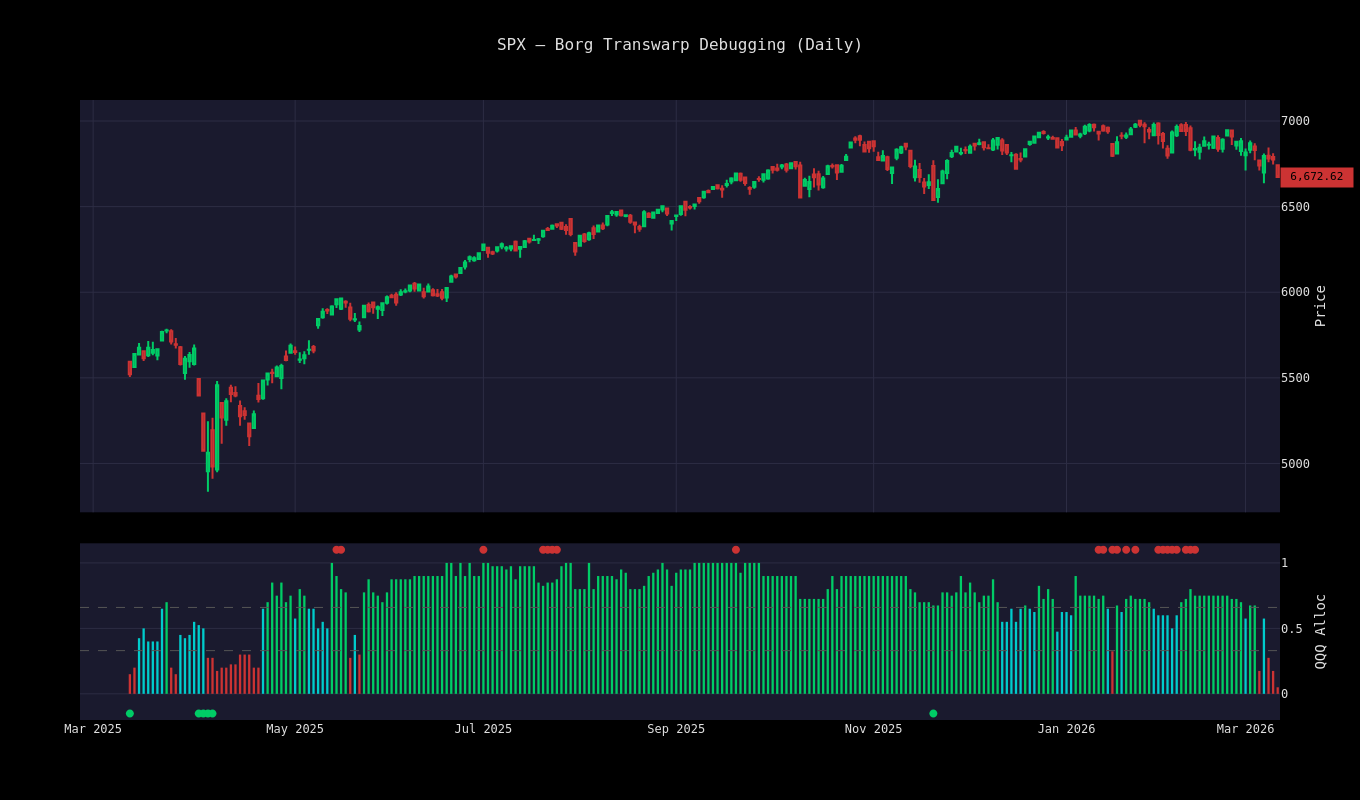

In [3]:
from options_analyzer.engine.borg_transwarp import compute_borg_transwarp_series
from options_analyzer.visualization.market_charts import plot_borg_candlestick

borg_closes = {sym: candle_data[sym].closes for sym in BORG_TICKERS if sym in candle_data}

# Align all Borg close arrays to the same length (some tickers may have fewer bars)
min_len = min(len(arr) for arr in borg_closes.values())
borg_closes = {sym: arr[-min_len:] for sym, arr in borg_closes.items()}
print(f"Borg closes aligned to {min_len} bars (warmup for RSI convergence)")

# Compute on full history, then trim to SPX display window
borg_results = compute_borg_transwarp_series(borg_closes)
display_len = len(spx_candles)
borg_results = borg_results[-display_len:]
print(f"Borg series: {len(borg_results)} bars (trimmed from {min_len} to match SPX display)")

fig = plot_borg_candlestick(
    borg_results,
    opens=spx_candles.opens,
    highs=spx_candles.highs,
    lows=spx_candles.lows,
    closes=spx_candles.closes,
    timestamps=spx_candles.timestamps,
    title="SPX — Borg Transwarp Debugging (Daily)",
)
fig.update_layout(height=800)
fig.show()

## 3. Cleanup

In [4]:
await providers.disconnect()
print("Session disconnected.")

Session disconnected.
